## 1   Import Dataset and libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

 

In [2]:
# Reproducibility
np.random.seed(42)

In [3]:
# Synthetic data: temperature (°C) vs. ice-cream sales (units/day)
temp = np.linspace(20, 40, 35) # Temperature from 20 to 40 degrees
noise = np.random.normal(0, 3, size=temp.shape)
sale = 2 * temp - 30+noise # Sales with some noise
data = pd.DataFrame({'Temperature': temp, 'IceCreamSales': sale})

data.head()


,Temperature,IceCreamSales
0,20.000000,11.490142
1,20.588235,10.761678
2,21.176471,14.296007
3,21.764706,18.098501
4,22.352941,14.003422


In [4]:
data.shape

(35, 2)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Temperature    35 non-null     float64
 1   IceCreamSales  35 non-null     float64
dtypes: float64(2)
memory usage: 692.0 bytes


In [6]:
data.describe()

,Temperature,IceCreamSales
count,35.000000,35.000000
mean,30.000000,29.602072
std,6.027618,11.949254
min,20.000000,10.761678
25%,25.000000,20.456026
50%,30.000000,28.116030
75%,35.000000,38.835445
max,40.000000,52.467635


## 2 Quick EDA

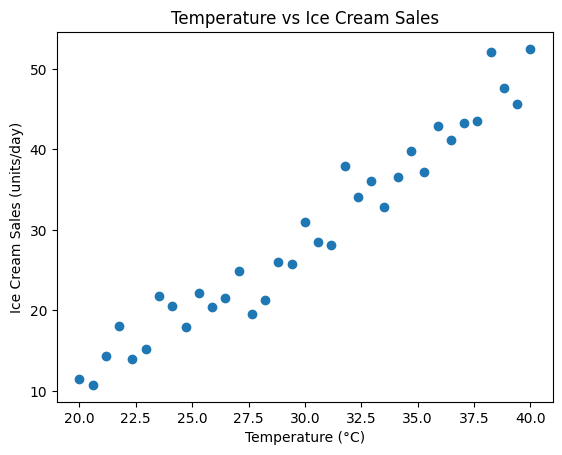

In [7]:
plt.scatter(data['Temperature'], data['IceCreamSales'])
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales (units/day)')
plt.title('Temperature vs Ice Cream Sales')
plt.show()

## 3    Train / Test Split

In [9]:

X = data['Temperature']
y = data['IceCreamSales']

X_train , X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)


In [10]:
X.head()


0    20.000000
1    20.588235
2    21.176471
3    21.764706
4    22.352941
Name: Temperature, dtype: float64

In [11]:
y.head()

0    11.490142
1    10.761678
2    14.296007
3    18.098501
4    14.003422
Name: IceCreamSales, dtype: float64

## Fit Linear Regression Model

In [13]:
# fitting the model
lin_reg = LinearRegression()
lin_reg.fit(X_train.to_frame(), y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
# Predicting.
y_pred = lin_reg.predict(X_test.to_frame())

rmse = np.sqrt(mean_squared_error(y_test , y_pred))
r2= r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.2f}")
print(f"R^2: {r2:.2f}")

RMSE: 2.91
R^2: 0.86


## True vs Predicted Plot

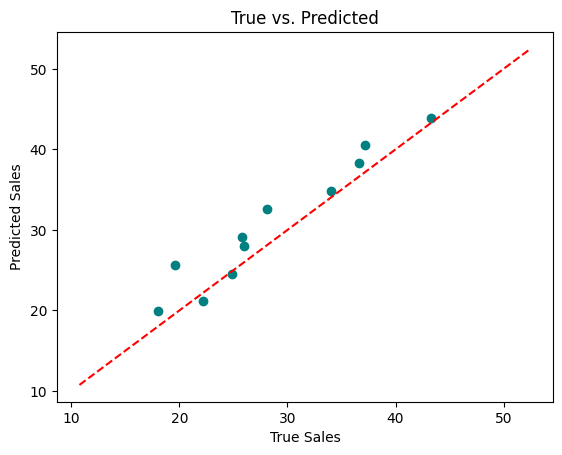

In [16]:
plt.scatter(y_test, y_pred, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 45° line
plt.xlabel('True Sales')
plt.ylabel('Predicted Sales')
plt.title('True vs. Predicted')
plt.show()